In [742]:
import pandas as pd 

In [743]:
#leemos el dataset
df = pd.read_csv("maternal-health-risk.csv")
df.tail()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [744]:
df.info()
#info general del dataset, vemos que no hay datos nulos

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [745]:
#esto para ver los datos duplicados
df.duplicated().sum()
#podemos observar 562 datos duplicados

np.int64(562)

In [746]:
#limpiamos los duplicados
# drop_duplicates() los borra, y reset_index() acomoda los números de las filas para que no queden huecos
df_limpio = df.drop_duplicates().reset_index(drop=True)

In [747]:
df_limpio.duplicated().sum() #aca visualizamos el dataset limpio, y lo guardamos en una nueva variable llamada df_limoio

np.int64(0)

In [748]:
df.shape #visualizamos cuantas filas y columnas tiene el dataset

(1014, 7)

In [749]:
df_limpio.shape #visualizamos cuantas filas y columnas tiene el nuevo dataset

(452, 7)

In [750]:
df_limpio.columns #buscamos nuestra variable objetivo, en este caso, tomamos RiskLevel que es lo que nos interesa, medir el nivel de riesgo

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='str')

In [751]:
df_limpio["RiskLevel"].unique() #vemos qu elos niveles de riesgo se dividen en, high low y mid (supongo que alto, bajo y medio)

<StringArray>
['high risk', 'low risk', 'mid risk']
Length: 3, dtype: str

In [752]:
df_limpio["RiskLevel"].map({ #visualizacion de como va a quedar
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
})



0      2
1      2
2      2
3      2
4      0
      ..
447    1
448    0
449    0
450    1
451    0
Name: RiskLevel, Length: 452, dtype: int64

In [753]:
df_limpio["RiskLevel"] = df_limpio["RiskLevel"].map({ #aca utilizamos map para hacer una Codificación de Etiquetas (Label Encoding), lo que hicimos fue, transformamos el texto en números para que el algoritmo pueda hacer sus cálculos
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
})
df_limpio.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [754]:
X = df_limpio[["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]] #guardamos en una variable X los valores que el modelo va a estudiar 
X

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76
...,...,...,...,...,...,...
447,12,100,50,6.4,98.0,70
448,15,100,60,6.0,98.0,80
449,15,100,49,7.6,98.0,77
450,12,100,50,6.0,98.0,70


In [755]:
y = df_limpio[["RiskLevel"]] #guardamos el valor de la variable objetivo, de lo que el modelo tiene que predecir
y

,RiskLevel
0,2
1,2
2,2
3,2
4,0
...,...
447,1
448,0
449,0
450,1


In [756]:
#utilizaremos un arbol de decision
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = DecisionTreeClassifier()

model.fit(X=X_train, y=y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [757]:
predicciones = model.predict(X_test)
precision = accuracy_score(y_test, predicciones)
precision

0.5752212389380531

In [758]:
resultado_prueba = model.predict([[ #lke pasamos valores nada mas para probar
80,	190,	100,	13.0,	99.0,	80
]])

c:\Users\Usuario\Desktop\IPF\PYTHON\maternal-health-risk-predict\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


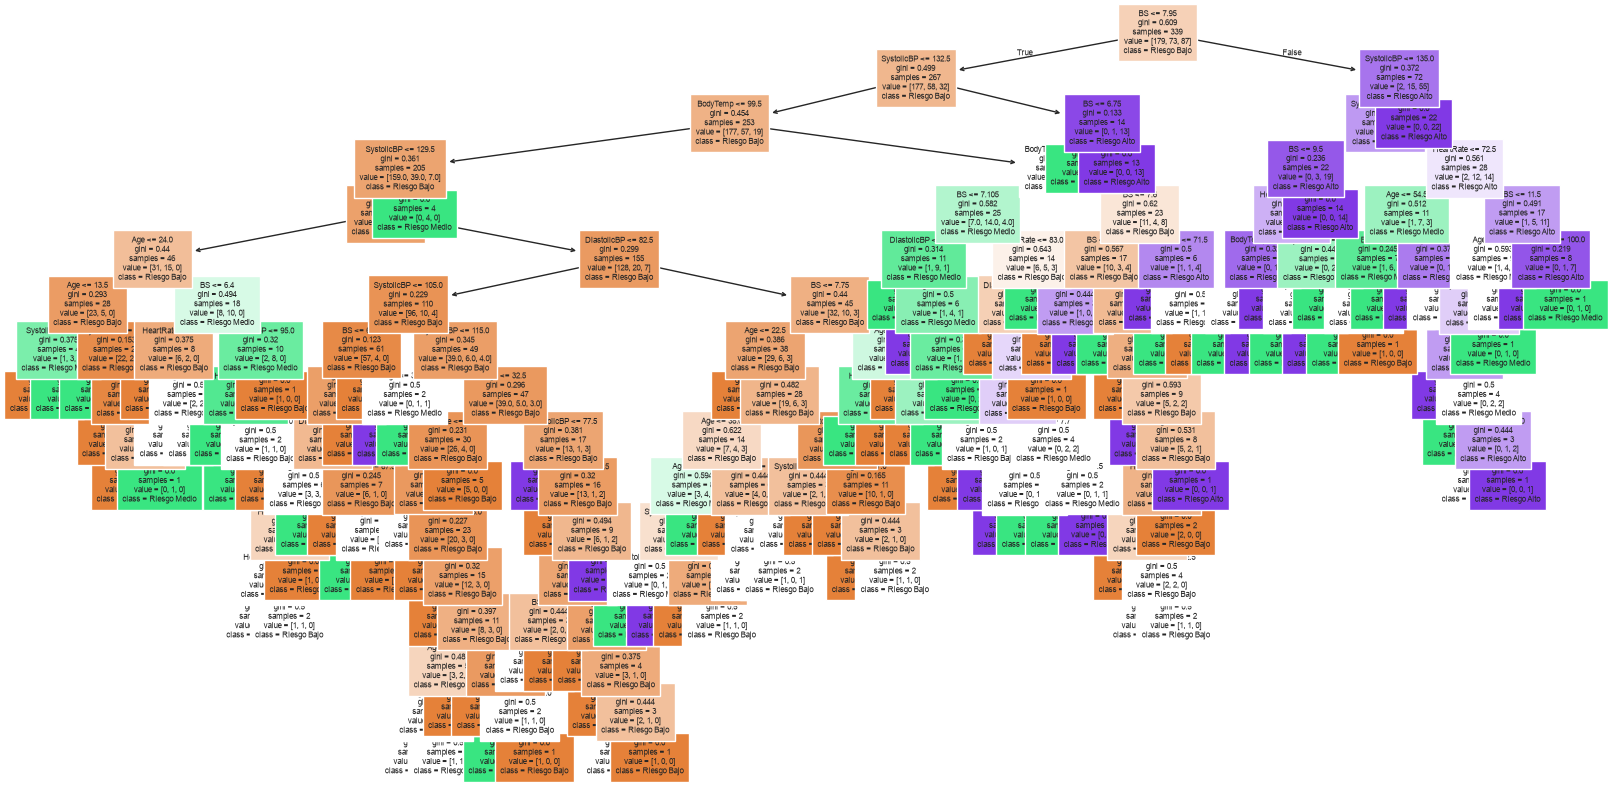

In [759]:
# 1. Importamos lo que nos falta para poder dibujar
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 2. Configuramos el tamaño de la hoja para que el gráfico gigante entre bien
plt.figure(figsize=(20, 10))

# 3. Dibujamos el árbol con las 3 clases de tu dataset de embarazadas
plot_tree(model, 
          feature_names=X_train.columns, 
          fontsize=6,
          class_names=["Riesgo Bajo", "Riesgo Medio", "Riesgo Alto"], 
          filled=True)

# 4. Mostramos el gráfico en la pantalla
plt.show()